# Analisis K-Means Clustering Polutan CO dengan Fokus Daerah Dukun

Notebook ini merupakan modifikasi dari pembahasan K-Means sebelumnya dengan fokus utama pada **Dukun, Gresik**. Analisis digunakan untuk melihat kemiripan karakteristik pola polutan CO antar-daerah berdasarkan fitur hasil ekstraksi TSFEL.

Tahapan utama:
1. Membaca data fitur CO hasil ekstraksi TSFEL.
2. Standardisasi fitur.
3. Reduksi dimensi menjadi **37 komponen PCA**.
4. Evaluasi jumlah cluster menggunakan **Elbow Method** dan **Silhouette Score**.
5. Membentuk cluster K-Means.
6. Memvisualisasikan hasil menggunakan PCA 1 dan PCA 2.
7. Mengidentifikasi posisi dan cluster **Dukun, Gresik**.
8. Membandingkan profil Dukun dengan daerah lain.
9. Mengecek file TSFEL 68 fitur khusus Dukun sebagai profil fitur.

> Catatan: file `CO_3Dukun_TSFEL(1).csv` yang diberikan hanya berisi **1 baris × 68 fitur**, sehingga tidak dapat digunakan sendirian untuk membentuk beberapa cluster. File tersebut digunakan sebagai profil fitur Dukun, sedangkan proses clustering dilakukan pada dataset gabungan yang memiliki banyak observasi.

## 1. Import Library

In [1]:
!pip install seaborn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 2. Membaca Data CO

In [3]:
# Dataset utama: hasil ekstraksi fitur CO dari beberapa daerah
path_data = "ekstraksi_fitur_co.csv"

# Profil TSFEL khusus Dukun: 1 observasi dengan 68 fitur
path_dukun = "CO_3Dukun_TSFEL.csv"

df = pd.read_csv(path_data)
df_dukun_68 = pd.read_csv(path_dukun)

print("Ukuran dataset utama :", df.shape)
print("Ukuran data Dukun 68 fitur :", df_dukun_68.shape)

display(df.head())
display(df_dukun_68.head())

Ukuran dataset utama : (37, 71)
Ukuran data Dukun 68 fitur : (1, 68)


,id,nama,daerah,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,calc_var,dfa,distance,ecdf,ecdf_percentile,ecdf_percentile_count,ecdf_slope,entropy,fundamental_frequency,higuchi_fractal_dimension,hist_mode,human_range_energy,hurst_exponent,interq_range,kurtosis,lempel_ziv,lpcc,max_frequency,max_power_spectrum,maximum_fractal_length,mean_abs_deviation,mean_abs_diff,mean_diff,median_abs_deviation,median_abs_diff,median_diff,median_frequency,mfcc,mse,negative_turning,neighbourhood_peaks,petrosian_fractal_dimension,pk_pk_distance,positive_turning,power_bandwidth,rms,skewness,slope,spectral_centroid,spectral_decrease,spectral_distance,spectral_entropy,spectral_kurtosis,spectral_positive_turning,spectral_roll_off,spectral_roll_on,spectral_skewness,spectral_slope,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,3,Nurhabibatul Umah,"Kerek, Tuban",0.325552,10.822536,3,0.000892,185.172183,0.038546,0.029654,0.029505,0.021616,0.003179,0.000010,1.042906,365,0.015027,0.029627,182.5,108.458864,0.998474,0.002732,1.901318,0.029235,0,0.742720,0.004623,-0.392904,0.188525,0.905428,0.393443,22.075911,-0.044002,0.002591,0.001930,0.000021,0.002318,0.001164,-0.000146,0.0,12.119794,1.252563,75,16,1.026565,0.016930,75,0.336066,0.029824,0.190216,0.000003,0.077955,-7.553302,-1210.997693,0.776339,4.628717,59,0.393443,0,1.674682,-0.044396,0.130288,0.554103,0.000015,0.704421,0.001815,0.008006,2.144113,0.007772,0.000069,0
1,4,Verdi Setyawan Ardiansyah Putra,Menganti Gresik,0.311946,10.599365,3,0.000855,183.614501,0.036701,0.029041,0.028905,0.020794,0.002986,0.000009,0.987874,365,0.015027,0.028924,182.5,129.729006,1.000000,0.002732,1.916911,0.029543,0,0.748064,0.003997,-0.257197,0.193989,0.911070,0.415301,32.511317,-0.043733,0.002403,0.001943,0.000019,0.002033,0.001272,-0.000199,0.0,14.603933,1.432786,74,17,1.026062,0.015907,74,0.387978,0.029194,0.211965,0.000001,0.082436,-7.475632,-1161.049478,0.814954,4.410509,61,0.415301,0,1.620868,-0.043240,0.135135,0.592456,0.000015,0.709078,0.001715,0.007520,2.139121,0.007297,0.000060,0
2,5,Okan Syailendra wahyudi,"Manyar, Gresik",0.306332,10.489406,3,0.000842,180.902553,0.036488,0.028827,0.028897,0.021112,0.002878,0.000008,0.998062,364,0.015068,0.028758,182.5,141.576148,1.000000,0.002740,1.881547,0.029569,0,0.819084,0.003986,-0.154798,0.186301,0.902928,0.378082,18.741802,-0.086948,0.002276,0.001713,0.000023,0.001923,0.001102,0.000112,0.0,11.976767,1.223360,66,18,1.023266,0.015375,65,0.312329,0.028970,0.052994,-0.000002,0.077472,-7.597746,-1167.052697,0.835311,4.545169,59,0.378082,0,1.645435,-0.044829,0.127778,0.661400,0.000014,0.623414,0.001676,0.007558,2.126252,0.007348,0.000061,0
3,6,Mochammad Zaenal Abidin,"Widang, Tuban",0.320845,10.744960,3,0.000879,184.819043,0.037897,0.029439,0.029169,0.021190,0.003156,0.000010,0.830604,365,0.015027,0.029376,182.5,101.640322,0.998474,0.002732,1.925278,0.027037,0,0.745385,0.004265,-0.177489,0.188525,0.905312,0.393443,55.370786,-0.048745,0.002549,0.001914,0.000018,0.002183,0.001312,0.000069,0.0,12.016886,1.267239,78,16,1.027568,0.016707,78,0.385246,0.029608,0.226369,0.000003,0.077480,-7.701349,-1195.411090,0.745865,4.804562,55,0.393443,0,1.703920,-0.044519,0.129537,0.474190,0.000013,0.698436,0.001767,0.007519,2.147071,0.007280,0.000060,0
4,7,M. Hendrik Purwanto,"Sreseh, Sampang",0.300128,10.334234,4,0.000831,178.342624,0.038664,0.028630,0.028280,0.021544,0.003069,0.000009,1.042484,361,0.015193,0.028522,180.5,107.078389,0.998455,0.002762,1.832444,0.027536,0,0.863764,0.004214,-0.177998,0.179558,0.918027,0.395028,21.949313,-0.114832,0.002473,0.001694,0.000007,0.002102,0.000879,0.000096,0.0,8.444976,0.804123,54,16,1.019508,0.017120,53,0.328729,0.028794,0.414033,-0.000003,0.075745,-7.546030,-1158.496513,0.792770,4.919090,58,0.395028,0,1.761275,-0.045455,0.130322,0.684887,0.000017,0.611650,0.001698,0.007830,2.098579,0.007624,0.00

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,calc_var,dfa,distance,ecdf,ecdf_percentile,ecdf_percentile_count,ecdf_slope,entropy,fundamental_frequency,higuchi_fractal_dimension,hist_mode,human_range_energy,hurst_exponent,interq_range,kurtosis,lempel_ziv,lpcc,max_frequency,max_power_spectrum,maximum_fractal_length,mean_abs_deviation,mean_abs_diff,mean_diff,median_abs_deviation,median_abs_diff,median_diff,median_frequency,mfcc,mse,negative_turning,neighbourhood_peaks,petrosian_fractal_dimension,pk_pk_distance,positive_turning,power_bandwidth,rms,skewness,slope,spectral_centroid,spectral_decrease,spectral_distance,spectral_entropy,spectral_kurtosis,spectral_positive_turning,spectral_roll_off,spectral_roll_on,spectral_skewness,spectral_slope,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.31295,10.58842,3.0,0.00086,182.402254,0.038594,0.029091,0.028833,0.020323,0.003336,0.000011,0.917194,364.00145,0.015068,0.028931,182.5,99.398302,0.999356,0.00274,1.852419,0.028545,0.0,0.802562,0.004875,-0.174817,0.175342,0.906714,0.421918,21.052426,-0.092724,0.002711,0.0019,0.000013,0.002421,0.001122,-0.000189,0.0,17.497902,1.238981,72.0,16.0,1.025637,0.018271,72.0,0.416438,0.029281,0.304184,5.668754e-07,0.081209,-7.002415,-1192.320387,0.777051,4.49369,57.0,0.421918,0.0,1.64552,-0.043854,0.133953,0.534442,0.000017,0.691652,0.00178,0.007723,2.12092,0.007492,0.000064,0.0


## 3. Pemeriksaan Data dan Identifikasi Dukun

Kolom `id`, `nama`, dan `daerah` diperlakukan sebagai identitas, bukan sebagai variabel numerik untuk clustering. Seluruh kolom TSFEL digunakan sebagai fitur.

In [4]:
print("Kolom dataset utama:")
print(df.columns.tolist())

print("\nInformasi daerah:")
display(df["daerah"].value_counts().reset_index(name="Jumlah").rename(columns={"index": "Daerah"}))

# Mencari observasi Dukun
dukun_mask = df["daerah"].astype(str).str.contains("Dukun", case=False, na=False)
df_dukun = df.loc[dukun_mask].copy()

print(f"Jumlah observasi Dukun pada dataset utama: {len(df_dukun)}")
display(df_dukun[["id", "nama", "daerah"]])

Kolom dataset utama:
['id', 'nama', 'daerah', 'abs_energy', 'auc', 'autocorr', 'average_power', 'calc_centroid', 'calc_max', 'calc_mean', 'calc_median', 'calc_min', 'calc_std', 'calc_var', 'dfa', 'distance', 'ecdf', 'ecdf_percentile', 'ecdf_percentile_count', 'ecdf_slope', 'entropy', 'fundamental_frequency', 'higuchi_fractal_dimension', 'hist_mode', 'human_range_energy', 'hurst_exponent', 'interq_range', 'kurtosis', 'lempel_ziv', 'lpcc', 'max_frequency', 'max_power_spectrum', 'maximum_fractal_length', 'mean_abs_deviation', 'mean_abs_diff', 'mean_diff', 'median_abs_deviation', 'median_abs_diff', 'median_diff', 'median_frequency', 'mfcc', 'mse', 'negative_turning', 'neighbourhood_peaks', 'petrosian_fractal_dimension', 'pk_pk_distance', 'positive_turning', 'power_bandwidth', 'rms', 'skewness', 'slope', 'spectral_centroid', 'spectral_decrease', 'spectral_distance', 'spectral_entropy', 'spectral_kurtosis', 'spectral_positive_turning', 'spectral_roll_off', 'spectral_roll_on', 'spectral_skewn

,daerah,Jumlah
0,"Kwanyar, Bangkalan",2
1,"Kamal, Bangkalan",2
2,"Kerek, Tuban",1
3,"Manyar, Gresik",1
4,Menganti Gresik,1
5,"Widang, Tuban",1
6,"Sreseh, Sampang",1
7,"Pilangkenceng, Madiun",1
8,"Tikala, Manado",1
9,"Cerme, Gresik",1


Jumlah observasi Dukun pada dataset utama: 1


,id,nama,daerah
24,28,Fathul Aziz Saifuddin,"Dukun, Gresik"


## 4. Menyiapkan Fitur dan Standardisasi

In [5]:
identitas = df[["id", "nama", "daerah"]].copy()
fitur_cols = [c for c in df.columns if c not in ["id", "nama", "daerah"]]

X = df[fitur_cols].copy()

# Pastikan seluruh fitur numerik
X = X.apply(pd.to_numeric, errors="coerce")

# Menangani nilai kosong bila ada
if X.isna().sum().sum() > 0:
    print("Terdapat nilai kosong. Nilai kosong diisi dengan median fitur.")
    X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Jumlah fitur TSFEL:", X.shape[1])
print("Ukuran matriks setelah standardisasi:", X_scaled.shape)

Jumlah fitur TSFEL: 68
Ukuran matriks setelah standardisasi: (37, 68)


## 5. Reduksi Dimensi menjadi 37 PCA

Sesuai pembahasan, data direduksi menjadi **37 komponen utama**. Karena dataset memiliki 68 fitur, PCA membantu merangkum informasi fitur sebelum K-Means.

In [6]:
n_pca = min(37, X_scaled.shape[0], X_scaled.shape[1])

pca = PCA(n_components=n_pca, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Jumlah komponen PCA:", n_pca)
print(f"Total variance yang dijelaskan oleh {n_pca} PCA: {cumulative[-1]:.4f} ({cumulative[-1]*100:.2f}%)")

Jumlah komponen PCA: 37
Total variance yang dijelaskan oleh 37 PCA: 1.0000 (100.00%)


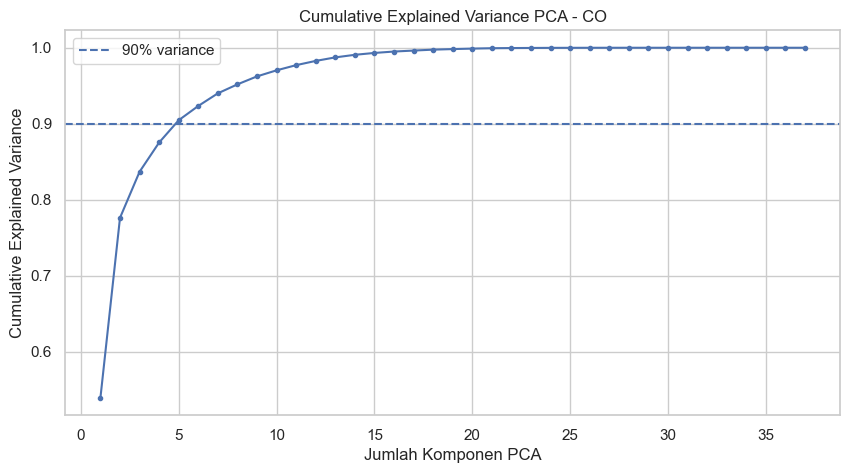

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_pca + 1), cumulative, marker="o", markersize=3)
plt.axhline(0.90, linestyle="--", label="90% variance")
plt.xlabel("Jumlah Komponen PCA")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance PCA - CO")
plt.legend()
plt.show()

## 6. Menentukan Jumlah Cluster

Dua ukuran digunakan secara bersamaan:

- **Elbow Method**: melihat penurunan inertia ketika jumlah cluster bertambah.
- **Silhouette Score**: mengukur seberapa baik observasi berada di cluster masing-masing. Nilai yang lebih tinggi menunjukkan pemisahan cluster yang lebih jelas.

Pemilihan `K` pada notebook ini dibuat berdasarkan hasil metrik, bukan langsung mengunci nilai tertentu.

In [8]:
K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

hasil_k = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias,
    "Silhouette": silhouettes
})

display(hasil_k)

,K,Inertia,Silhouette
0,2,1123.800303,0.795494
1,3,660.214101,0.697034
2,4,509.373825,0.342517
3,5,413.889526,0.184501
4,6,361.351576,0.153812
5,7,315.868398,0.161337
6,8,272.854136,0.142490
7,9,239.322559,0.150055
8,10,221.039012,0.145469


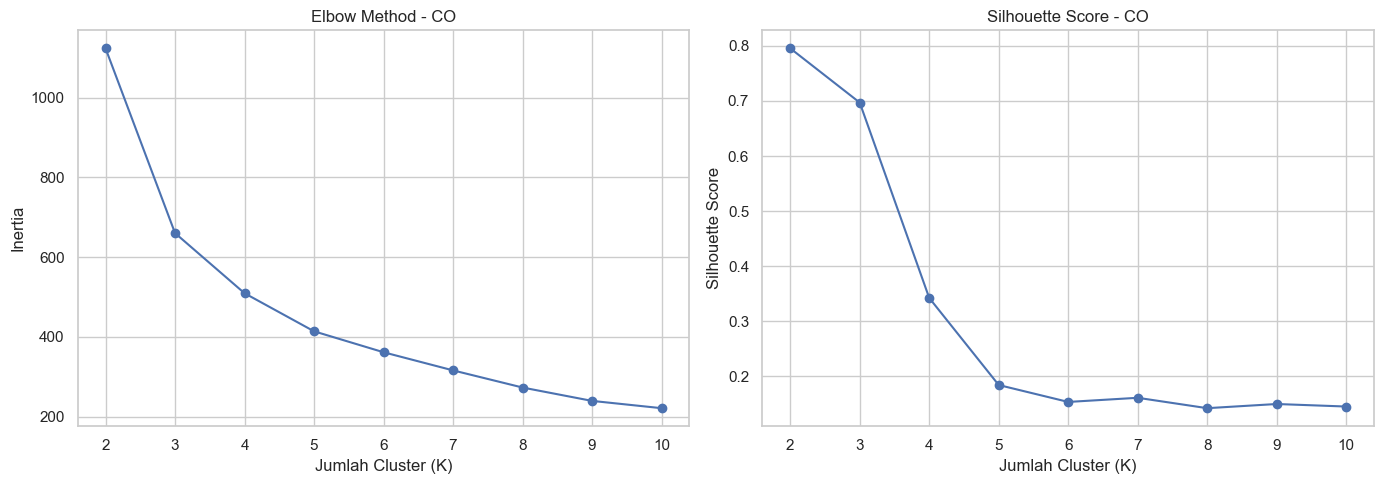

K dengan Silhouette Score tertinggi: 2


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(hasil_k["K"], hasil_k["Inertia"], marker="o")
ax[0].set_title("Elbow Method - CO")
ax[0].set_xlabel("Jumlah Cluster (K)")
ax[0].set_ylabel("Inertia")

ax[1].plot(hasil_k["K"], hasil_k["Silhouette"], marker="o")
ax[1].set_title("Silhouette Score - CO")
ax[1].set_xlabel("Jumlah Cluster (K)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

k_silhouette = int(hasil_k.loc[hasil_k["Silhouette"].idxmax(), "K"])
print("K dengan Silhouette Score tertinggi:", k_silhouette)

### Catatan interpretasi K

Silhouette Score digunakan sebagai indikator kuantitatif tambahan. Grafik Elbow tetap perlu dilihat untuk mengetahui apakah terdapat titik perubahan inertia yang jelas. Dengan demikian, nilai `K` yang dipakai pada tahap akhir dapat dibandingkan antara kedua pendekatan tersebut.

## 7. K-Means Final

In [10]:
# Menggunakan K dengan Silhouette Score tertinggi sebagai titik awal analisis
K_FINAL = k_silhouette

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

df_hasil = identitas.copy()
df_hasil["Cluster"] = cluster_labels

print(f"Jumlah cluster yang digunakan: {K_FINAL}")
display(df_hasil.head(10))

Jumlah cluster yang digunakan: 2


,id,nama,daerah,Cluster
0,3,Nurhabibatul Umah,"Kerek, Tuban",0
1,4,Verdi Setyawan Ardiansyah Putra,Menganti Gresik,0
2,5,Okan Syailendra wahyudi,"Manyar, Gresik",0
3,6,Mochammad Zaenal Abidin,"Widang, Tuban",0
4,7,M. Hendrik Purwanto,"Sreseh, Sampang",0
5,8,Robbaniyah Umdatun Ni'mah,"Cerme, Gresik",0
6,10,Ainur Raftuzzaki,Nunukan,0
7,11,Magdalena Jovita Hatuopar,"Pilangkenceng, Madiun",0
8,12,Rachelia Andini Tendean,"Tikala, Manado",0
9,13,Kurnia Maulinda Sari,"Labang, Bangkalan",0


## 8. Visualisasi PCA 1 dan PCA 2

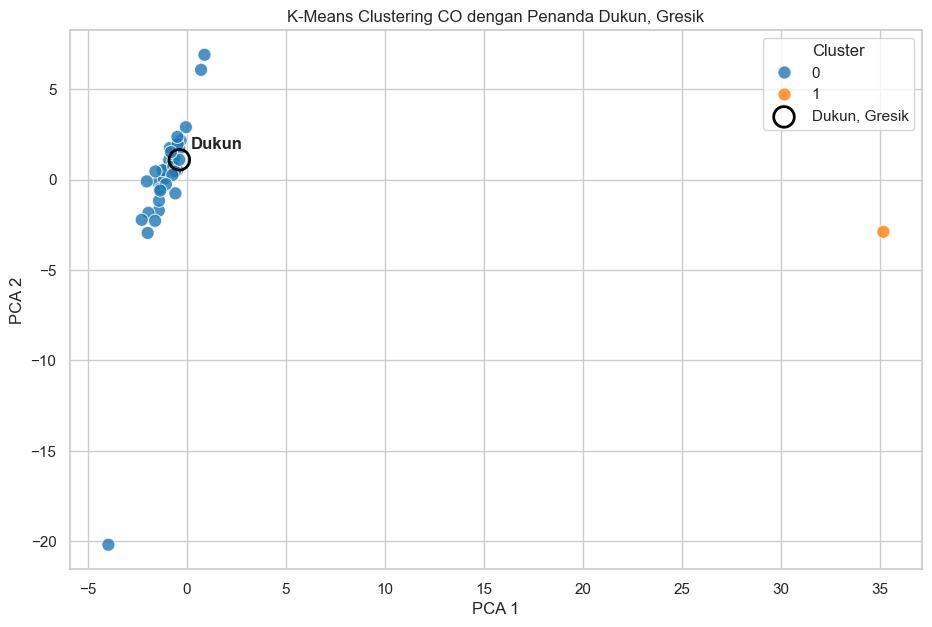

In [11]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_hasil["Cluster"].astype(str),
    palette="tab10",
    s=90,
    alpha=0.8
)

# Tandai observasi Dukun
dukun_idx = np.where(dukun_mask.values)[0]

if len(dukun_idx) > 0:
    plt.scatter(
        X_pca[dukun_idx, 0],
        X_pca[dukun_idx, 1],
        s=220,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label="Dukun, Gresik"
    )

    for i in dukun_idx:
        plt.annotate(
            "Dukun",
            (X_pca[i, 0], X_pca[i, 1]),
            xytext=(8, 8),
            textcoords="offset points",
            fontweight="bold"
        )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering CO dengan Penanda Dukun, Gresik")
plt.legend(title="Cluster")
plt.show()

## 9. Posisi Dukun di Dalam Cluster

Bagian ini secara khusus melihat Dukun, bukan hanya persebaran seluruh daerah. Hasil berikut menunjukkan cluster tempat observasi Dukun berada.

In [12]:
if len(df_dukun) > 0:
    display(df_hasil[df_hasil["daerah"].str.contains("Dukun", case=False, na=False)])

    dukun_cluster = df_hasil.loc[
        df_hasil["daerah"].str.contains("Dukun", case=False, na=False),
        "Cluster"
    ].tolist()

    print("Cluster Dukun:", dukun_cluster)
else:
    print("Tidak ditemukan observasi dengan nama daerah Dukun.")

,id,nama,daerah,Cluster
24,28,Fathul Aziz Saifuddin,"Dukun, Gresik",0


Cluster Dukun: [0]


## 10. Komposisi Daerah pada Setiap Cluster

In [13]:
profil_daerah = (
    df_hasil
    .groupby(["Cluster", "daerah"])
    .size()
    .reset_index(name="Jumlah")
    .sort_values(["Cluster", "Jumlah"], ascending=[True, False])
)

display(profil_daerah)

print("\nCluster yang berisi Dukun:")
if len(df_dukun) > 0:
    d_cluster = df_hasil.loc[dukun_mask, "Cluster"].iloc[0]
    display(profil_daerah[profil_daerah["Cluster"] == d_cluster])

,Cluster,daerah,Jumlah
7,0,"Kamal, Bangkalan",2
15,0,"Kwanyar, Bangkalan",2
0,0,"Asemrowo, Surabaya",1
1,0,"Bandung, Jogoroto, Jombang",1
2,0,"Banyu Ajuh, Perumnas, Kamal",1
3,0,Baron Nganjuk,1
4,0,"Cerme, Gresik",1
5,0,"Dukun, Gresik",1
6,0,"Gresik Kota, Gresik",1
8,0,"Kec. Bangkalan, Kab. Bangkalan",1



Cluster yang berisi Dukun:


,Cluster,daerah,Jumlah
7,0,"Kamal, Bangkalan",2
15,0,"Kwanyar, Bangkalan",2
0,0,"Asemrowo, Surabaya",1
1,0,"Bandung, Jogoroto, Jombang",1
2,0,"Banyu Ajuh, Perumnas, Kamal",1
3,0,Baron Nganjuk,1
4,0,"Cerme, Gresik",1
5,0,"Dukun, Gresik",1
6,0,"Gresik Kota, Gresik",1
8,0,"Kec. Bangkalan, Kab. Bangkalan",1


## 11. Daerah yang Paling Dekat dengan Dukun pada Ruang PCA

Selain melihat cluster yang sama, jarak ke titik Dukun dapat digunakan untuk mencari observasi yang secara matematis memiliki karakteristik paling dekat pada ruang PCA. Ini membantu memperjelas daerah mana yang memiliki pola fitur CO yang mirip dengan Dukun.

In [14]:
if len(df_dukun) > 0:
    d_idx = np.where(dukun_mask.values)[0][0]

    distances = np.linalg.norm(X_pca - X_pca[d_idx], axis=1)

    kedekatan_dukun = df_hasil[["id", "nama", "daerah", "Cluster"]].copy()
    kedekatan_dukun["Jarak_dari_Dukun"] = distances

    # Dukun sendiri dikeluarkan dari daftar tetangga
    kedekatan_dukun = kedekatan_dukun.drop(index=d_idx)

    display(
        kedekatan_dukun
        .sort_values("Jarak_dari_Dukun")
        .head(10)
    )
else:
    print("Analisis jarak tidak dapat dilakukan karena Dukun tidak ditemukan.")

,id,nama,daerah,Cluster,Jarak_dari_Dukun
11,15,Ahmad Dafi Zidni Alfarisi,"Paciran, Lamongan",0,2.210471
17,21,Triswanti Jannatul Ma'wa,Kedungpring Lamongan,0,2.789627
1,4,Verdi Setyawan Ardiansyah Putra,Menganti Gresik,0,3.128675
22,26,A. Choiril Anwar El-Asfihani Risydan,"Banyu Ajuh, Perumnas, Kamal",0,3.302830
9,13,Kurnia Maulinda Sari,"Labang, Bangkalan",0,3.613083
16,20,AHMAD MAULANA ISHAQ,"Kertosono, Ngajuk",0,3.757717
0,3,Nurhabibatul Umah,"Kerek, Tuban",0,3.806867
21,25,Laila Maghfiroh,"Kamal, Bangkalan",0,3.837875
12,16,Rian Renaldy,"Waru, Pamekasan",0,3.873895
15,19,Deo Candra Saputra,"Widodaren, Ngawi",0,3.904710


## 12. Analisis Khusus 68 Fitur TSFEL Dukun

File `CO_3Dukun_TSFEL(1).csv` berisi satu observasi Dukun dengan 68 fitur TSFEL. Karena hanya satu observasi, data ini **bukan dataset yang cukup untuk menjalankan K-Means secara mandiri**.

Namun, distribusi nilai fiturnya dapat diperiksa untuk mengetahui karakteristik ekstraksi fitur Dukun.

In [15]:
# Statistik fitur Dukun
dukun_stats = df_dukun_68.describe().T
dukun_stats["abs_value"] = dukun_stats["mean"].abs()

display(dukun_stats.sort_values("abs_value", ascending=False).head(15))

,count,mean,std,min,25%,50%,75%,max,abs_value
spectral_distance,1.0,-1192.320387,NaN,-1192.320387,-1192.320387,-1192.320387,-1192.320387,-1192.320387,1192.320387
distance,1.0,364.001450,NaN,364.001450,364.001450,364.001450,364.001450,364.001450,364.001450
ecdf_percentile_count,1.0,182.500000,NaN,182.500000,182.500000,182.500000,182.500000,182.500000,182.500000
calc_centroid,1.0,182.402254,NaN,182.402254,182.402254,182.402254,182.402254,182.402254,182.402254
ecdf_slope,1.0,99.398302,NaN,99.398302,99.398302,99.398302,99.398302,99.398302,99.398302
negative_turning,1.0,72.000000,NaN,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
positive_turning,1.0,72.000000,NaN,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
spectral_positive_turning,1.0,57.000000,NaN,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
max_power_spectrum,1.0,21.052426,NaN,21.052426,21.052426,21.052426,21.052426,21.052426,21.052426
mfcc,1.0,17.497902,NaN,17.497902,17.497902,17.497902,17.497902,17.497902,17.497902


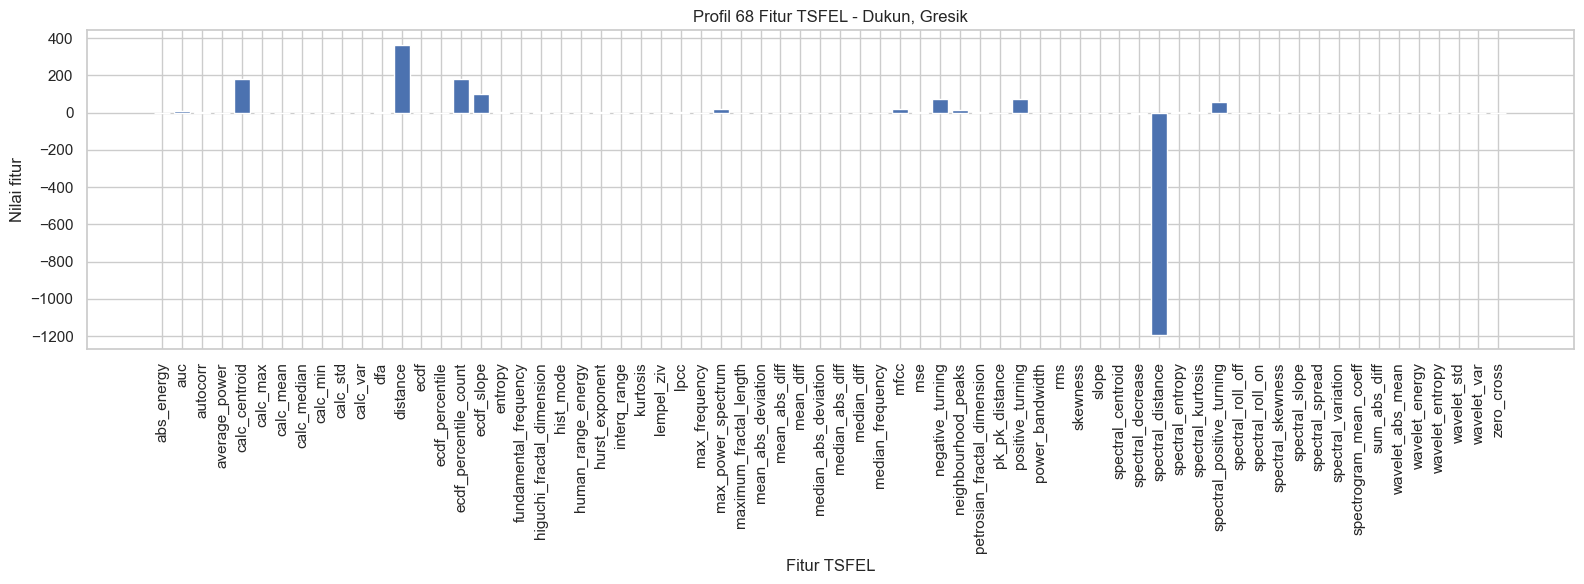

In [16]:
# Visualisasi nilai seluruh 68 fitur Dukun
plt.figure(figsize=(16, 6))
plt.bar(range(len(df_dukun_68.columns)), df_dukun_68.iloc[0].values)
plt.xticks(range(len(df_dukun_68.columns)), df_dukun_68.columns, rotation=90)
plt.xlabel("Fitur TSFEL")
plt.ylabel("Nilai fitur")
plt.title("Profil 68 Fitur TSFEL - Dukun, Gresik")
plt.tight_layout()
plt.show()

## 13. Kesimpulan yang Perlu Ditulis pada Laporan

Gunakan hasil angka dan grafik yang muncul setelah notebook dijalankan. Fokus pembahasannya adalah:

1. Dataset CO memiliki sejumlah observasi daerah dengan fitur hasil ekstraksi TSFEL.
2. Standardisasi dilakukan sebelum PCA dan K-Means agar skala antarfitur tidak mendominasi jarak.
3. PCA digunakan untuk merangkum 68 fitur menjadi 37 komponen.
4. Jumlah cluster dievaluasi menggunakan Elbow Method dan Silhouette Score.
5. Posisi **Dukun, Gresik** diperiksa secara khusus untuk mengetahui cluster dan kedekatannya dengan daerah lain.
6. Jika Dukun berada dalam cluster yang sama dengan beberapa daerah lain, interpretasinya adalah bahwa observasi tersebut memiliki kemiripan pola fitur CO pada ruang fitur yang digunakan. Hal ini tidak berarti kondisi pencemaran di daerah tersebut identik.
7. File 68 fitur khusus Dukun digunakan sebagai profil fitur dan tidak digunakan sebagai dataset K-Means mandiri karena hanya memiliki satu observasi.